# Desafio Alura: Analisis de Cancelaciones para Telecom X

La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.
Este trabajo se enfoca en recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa.

#### Diccionario de datos (original)

- `customerID`: número de identificación único de cada cliente
- `Churn`: cliente dejó la empresa
- `gender`: género
- `SeniorCitizen`: cliente mayor a 64 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

### Diccionario de datos (nuevo)

- `customer_id`:       número de identificación único de cada cliente
- `churn`:             cliente dejó la empresa (1:Sí, 0:No)
_____
- `gender_male`:       género (1:masculino, 0:femenino)
- `senior_citizen_65`: cliente mayor a 64 años (1:Sí, 0:No)
- `partner`:           cliente tiene una pareja (1:Sí, 0:No)
- `dependents`:        cliente tiene dependientes (1:Sí, 0:No)
- `tenure`: meses de contrato del cliente
_____
- `phone_service`:     cliente suscrito al servicio telefónico (1:Sí, 0:No)
- `multiple_lines`:    cliente suscrito a más de una línea telefónica (1:Sí, 0:No)
______
- `internet_service`:  cliente suscrito a un proveedor de internet (1:Sí, 0:No)
- `online_security`:   cliente suscrito al seguridad en línea (1:Sí, 0:No)
- `online_backup`:     cliente suscrito a respaldo en línea (1:Sí, 0:No)
- `device_protection`: cliente suscrito a protección del dispositivo (1:Sí, 0:No)
- `tech_support`:      cliente suscrito a soporte técnico (1:Sí, 0:No)
- `streaming_tv`:      cliente suscrito a televisión por cable (1:Sí, 0:No)
- `streaming_movies`:  cliente suscrito a streaming de películas (1:Sí, 0:No)
_______
- `contract`: tipo de contrato (month_to_month, one_year, two_year)
- `paperless_billing`: cliente prefiere recibir la factura en línea (1:Sí, 0:No)
- `payment_method`:    forma de pago
- `charges_monthly`:   total de todos los servicios del cliente por mes
- `charges_total`:     total gastado por el cliente


## Diccionario (variables agregadas)


- `family`: El cliente tiene pareja o dependientes. (1:sí, 0:no)
- `tenure_log`: logaritmo de la antigüedad del cliente.
______
- `dsl`: toma el valor 1 si el servicio de internet es por DSL, 0 en otro caso.
- `fiber_optic`: toma el valor 1 si el servicio de internet es por fibra optica, 0 en otro caso.
- `no_internet`: toma el valor 1 si no hay servicio de internet.
______
- `subcription_total`: Cuenta la cantidad de servicios a lo que el usuario esta subscrito.
- `subcription_no_streaming`: Cuenta la cantidad de servicios a lo que el usuario esta subscrito, ignorando los de streaming
- `streaming`: cliente suscrito a streaming_tv o streaming_movies (1:sí, 0:no)
______
- `month_to_month`: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.
- `one_year`: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.
- `two_year`: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.
______
- `charges_average` : Se suman los gaston mensuales y totales (los gastos acumulados más los gastos de este mes)  y se dividen por tenure + 1 (contando el mes).
- `charges_average_log` : logaritmo de los gastos promedios.
- `charges_total_log` : logaritmo de los gastos totales.
_____
- `electronic_check`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- `mailed_check`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- `bank_transfer_automatic`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- `credit_card_automatic`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
- `automatic_payment`: : toma el valor 1 si el método de pago es credit_card_automatic o bank_transfer_automatic, 0 en otro caso.


## Librerías

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.colors import LinearSegmentedColormap





## Funciones

#### Comboplot

Input: un pandas dataset (data) y el nombre en formato string de una variable para realizar el gráfico de columnas (var).
Output: un gráfico combinado de columnas para la variable provista (var) y un gráfico de linea para el porcentaje de churn en cada nivel de dicha variable. Si se provee el argumento opcional *group* entonces se proveen varias líneas.

In [5]:
def comboplot(data, var, group = None,
              xlabel = None, xlim=None , ylim=None, churnlim = None , xticks=None,
              title = None, legend=None, barwidth = None , color = None):

  if data["churn"].dtype == "O":
    data["churn"] = data["churn"].replace({"No canceló": "0", "Canceló": "1"}).astype(int)




  if group is None:
    summary = (
        data.assign(cancelled =   data["churn"] == 1)
          .groupby(var)
          .agg(
              total_customers=("cancelled", "size"),
              churn_rate=("cancelled", "mean")
          )
          .reset_index()
    )

  else:
    summary = (
        data.assign(cancelled =   data["churn"] == 1)
          .groupby([var, group])
          .agg(
              total_customers=("cancelled", "size"),
              churn_rate=("cancelled", "mean")
          )
          .reset_index()
    )


  summary["churn_rate"] *= 100  # percentage

  fig, ax1 = plt.subplots()

  # Bar plot: number of customers
  ax1.bar(summary[var], summary["total_customers"], width=barwidth)
  ax1.set_ylabel("Cantidad")

  if xlabel is not None:
    ax1.set_xlabel(xlabel)
  if ylim is not None:
    ax1.set_ylim(ylim)
  if ylim is not None:
    ax1.set_xlim(xlim)
  if xticks is not None:
    ax1.set_xticks(xticks)

  # Line plot: churn percentage
  ax2 = ax1.twinx()

  if group is None:
     ax2.plot(summary[var], summary["churn_rate"], marker="o", color = "red")
  else:
    for tg, g in summary.groupby(group):
      ax2.plot(
        g[var],
        g["churn_rate"],
        marker="o",
        label=f"{tg}",
        color = color[tg])
      if legend is None:
        legend = group
      #ax2.legend(title= legend)
      #plt.legend(loc='best')

    ax2.legend(title= legend)




  ax2.set_ylabel("Churn (%)")
  ax2.set_ylim(churnlim)
  ax2.axhline(y = 27 , color = "grey", ls="dashed")

  plt.title(title)
  plt.show()




### pretty_churn

In [6]:
def pretty_churn(df):
  header_color = "#1f4e79"   # dark blue
  index_color  = "#dce6f2"   # pale blue
  if df["churn"].dtype == "int":
    df["churn"] = df["churn"].astype(str).replace({"0": "No canceló", "1": "Canceló"})
  styled = (
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Porcentaje (%)")
    .to_frame()
    .style
    .format("{:.0f}%")
    .set_caption("Cancelación de los clientes")
    .background_gradient(cmap="RdBu_r", axis = None)

        # ---- Alignment ----
        .set_properties(**{
            "text-align": "left"
        })

        # ---- Borders ----
        .set_table_styles([
            # Header
            {"selector": "th",
             "props": [
                 ("background-color", header_color),
                 ("color", "white"),
                 ("font-weight", "bold"),
                 ("font-size", "16px"),
                 ("border", "1px solid white"),
                  ("text-align", "left")
             ]},

            # Table cells
            {"selector": "td",
             "props": [
                 ("font-size", "16px"),
                 ("padding", "8px"),
                 ("border", "1px solid white"),
                 ("text-align", "center")
             ]}
        ])

        # ---- Index styling ----
        .set_table_styles([
            {"selector": ".row_heading",
             "props": [
                 ("background-color", index_color),
                 ("font-size", "16px"),
                  ("color", "black"),
                 ("font-weight", "bold"),
                 ("border", "1px solid white"),
                 ("text-align", "left")
             ]}
        ], overwrite=False)
)


  df["churn"] = df["churn"].replace({"No canceló": "0", "Canceló": "1"}).astype(int)

  return styled

### pretty_table
Input:
- df un pandas dataset
- vars: una lista con los nombres de las variables
- label: una lista de diccionarios, cada diccionario contiene los valores de la variable y su etiqueta.
- var_labels: una lista con las etiquetas de la variables, por defecto utiliza los nombres originals (vars).

Output:
- Una tabla con los conteos totales y el porcentaje de rechazo para cada valor de todas las variables seleccionadas.

In [7]:
def pretty_table(df, vars, labels, var_labels=None, total=True, churn_col="churn"):

    if var_labels is None:
      var_labels = vars
    if df[churn_col].dtype == "O":
        df[churn_col] = df[churn_col].replace({"No canceló": "0", "Canceló": "1"}).astype(int)

    rows = []

    for var, lab, var_lab in zip(vars, labels, var_labels):
        if len(lab) == 0:
            values = sorted(df[var].dropna().unique())
            lab = {v: str(v) for v in values}

        for value, level_name in lab.items():
            mask = df[var] == value
            churn_rate = df.loc[mask, churn_col].mean() * 100 if mask.sum() > 0 else float("nan")

            rows.append({
                "Variable": var_lab,
                "Level": level_name,
                "Total": mask.sum(),
                "Churn (%)": round(churn_rate, 0),
            })

    if total:
        rows.append({
            "Variable": "Total",
            "Level": "",
            "Total": df[churn_col].count(),
            "Churn (%)": df[churn_col].mean() * 100,
        })

    table = pd.DataFrame(rows)

    # Visual grouping
    table.loc[table["Variable"].duplicated(), "Variable"] = ""

    header_color = "#1f4e79"   # dark blue
    index_color  = "#dce6f2"   # pale blue

    styled = (
        table.style
        .format({
            "Churn (%)": "{:.0f}%",
            "Total": "{:,.0f}"
        })

        # ---- Gradient ONLY on churn ----
        .background_gradient(
            cmap="RdBu_r",
            subset=["Churn (%)"]
        )

        # ---- Background + default alignment ----
        .set_properties(
            subset=table.columns.difference(["Churn (%)"]),
            **{
                "background-color": index_color,
                "text-align": "left",
                "color": "black",

            }
        )

        # ---- Table styles ----
        .set_table_styles([
            {"selector": "th",
             "props": [
                 ("background-color", header_color),
                 ("color", "white"),
                 ("font-weight", "bold"),
                 ("font-size", "16px"),
                 ("border", "1px solid white"),
                 ("text-align", "left")
             ]},
            {"selector": "td",
             "props": [

                 ("font-size", "16px"),
                 ("padding", "8px"),
                 ("border", "1px solid white")
             ]}
        ])

        # ---- Index styling ----
        .set_table_styles([
            {"selector": ".row_heading",
             "props": [
                 ("background-color", index_color),
                 ("font-size", "16px"),
                 ("color", "black"),
                 ("font-weight", "bold"),
                 ("border", "1px solid white"),
                 ("text-align", "left")
             ]}
        ], overwrite=False)

        # ---- Center churn column ----
        .set_properties(
            subset=["Churn (%)"],
            **{"text-align": "center",
                "font-weight": "bold",}
        )
        #----- hide index ----

        .hide(axis="index")
    )

    start_rows = table.index[table["Variable"] != ""]

    styled = styled.set_table_styles(
        [
            {
                "selector": f"tbody tr:nth-child({i+1}) td",
                "props": [("border-top", "3px solid white")]
            }
            for i in start_rows
        ],
    overwrite=False
)

    return styled


### pretty_table_numeric

In [42]:
def pretty_table_numeric( data, cols, var_labels):
  def cohens_d(x1, x2):
    n1, n2 = len(x1), len(x2)
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)

    s_pooled = ((n1 - 1)*s1**2 + (n2 - 1)*s2**2) / (n1 + n2 - 2)
    s_pooled = s_pooled**0.5
    d = abs(x1.mean() - x2.mean()) / s_pooled

    return d.round(2)

  def cohen_interpretation(d):
    a = abs(d)

    if a < 0.10:
        return "Despreciable"
    elif a < 0.30:
        return "Pequeño"
    elif a < 0.50:
        return "Pequeño–medio"
    elif a < 0.80:
        return "Medio"
    else:
        return "Grande"


  def cohen_color_from_d(d):
    a = abs(d)

    if a < 0.10:
        return "background-color: #1f4e79; color: white"   # azul
    elif a < 0.30:
        return "background-color: white"
    elif a < 0.50:
        return "background-color: #f4b183"                 # naranja
    elif a < 0.80:
        return "background-color: #c00000; color: white"   # rojo
    else:
        return "background-color: #7f0000; color: white"   # rojo oscuro

  def color_interpretation(row):
    return [""] * (len(row) - 1) + [cohen_color_from_d(row["Cohen's d"])]

# Etiquetas claras
  if data["churn"].dtype == "int":
    data["churn"] = data["churn"].astype(str).replace({
      "0": "No canceló",
      "1": "Canceló"
      })

  rows = {}

  for col in cols:
    row = {}
    for g in ["No canceló", "Canceló"]:
      x = data.loc[data["churn"] == g, col].dropna()
      row[g] = f"{x.mean():.2f} ({x.std(ddof=1):.2f})"
    rows[col] = row

  summary = (
      pd.DataFrame.from_dict(rows, orient="index")
      .rename_axis("Atributo")
    )


  d_values = {}

  for col in cols:
    x_cancel = df.loc[df["churn"] == "Canceló", col].dropna()
    x_no     = df.loc[df["churn"] == "No canceló", col].dropna()
    d_values[col] = cohens_d(x_cancel, x_no)

  cohen_df = (
    pd.DataFrame.from_dict(d_values, orient="index", columns=["Cohen's d"])
    .rename_axis("Atributo")
  )

# Interpretación del tamaño del efecto
  cohen_df["Interpretación de la diferencia"] = cohen_df["Cohen's d"].apply(cohen_interpretation)


  final_table = summary.join(cohen_df)

  final_table = final_table.loc[
    final_table["Cohen's d"].abs().sort_values(ascending=False).index
]

  if var_labels is not None:
    label_map = dict(zip(cols, var_labels))
    final_table = final_table.rename(index=label_map)





  header_color = "#1f4e79"
  index_color  = "#dce6f2"


  styled_final = (
    final_table
      .style
      .hide(subset=["Cohen's d"], axis='columns')
      .apply(color_interpretation, axis=1)
       .set_properties(**{
            "font-size": "16px",
            "padding": "8px",
            "text-align": "right"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [
                 ("background-color", header_color),
                 ("color", "white"),
                 ("font-weight", "bold"),
                 ("font-size", "16px"),
                 ("text-align", "left"),
                 ("border", "1px solid white")
             ]},
            {"selector": ".row_heading",
             "props": [
                 ("background-color", index_color),
                 ("color", "black"),
                 ("font-weight", "bold"),
                 ("font-size", "16px"),
                 ("text-align", "left"),
                 ("border", "1px solid white")
             ]},
            {"selector": "td",
             "props": [
                 ("background-color", index_color),
                 ("border", "1px solid white"),
                 ("color", "black"),
                 ("text-align", "right")
             ]}
        ])


)
  print("Los resultados se presentan en formato Media (Desvíos Estandar)\nLa interpretación se basa en la d de Cohen")
  return styled_final

### pretty_correlation

Input:
- data: un pandas dataframe, preferentemente de variables numéricas.
- vars: una lista con los nombres de las variables a considerar

Output:
- Una matriz de correlación, con un mapa de calor.

In [9]:
# Matriz de correlación

def pretty_correlation(data, vars=None):
    if vars is None:
        vars = list(data.columns)

    if df["churn"].dtype == "O":
        df["churn"] = df["churn"].replace({"No canceló": "0", "Canceló": "1"}).astype(int)+0

    corr = df[vars].corr(numeric_only=True).round(2)

    styled = (
        corr.style
        .format("{:.2f}")
        .background_gradient(
            cmap="RdBu_r",
            vmin=-1,
            vmax=1
        )
        .set_properties(**{
            "font-size": "14px",
            "text-align": "center"
        })
        .set_table_styles([
            {"selector": "th",
             "props": [
                 ("font-weight", "bold"),
                 ("font-size", "14px"),
                 ("text-align", "center")
             ]}
        ])
    )

    return styled




# Importación de datos

In [10]:
#Fuente original de los datos
# url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
#Mirror:
url = "https://raw.githubusercontent.com/TheNaranjero/Challenge-2-Data-Science/refs/heads/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


# Limpieza de la base
Normalizamos los datos contenidos en formato JSON.

In [12]:
customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account  = pd.json_normalize(df["account"])

df = pd.concat([df['customerID'], df['Churn'], customer, phone, internet, account], axis=1)

df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


Estandarizado de los nombrs de las variables a snake_case:

In [13]:
df = df.rename(columns={'customerID': 'customer_id',
                        'Churn': 'churn',
                        'gender': 'gender',
                        'SeniorCitizen': 'senior_citizen',
                        'Partner': 'partner',
                        'Dependents': 'dependents',
                        'tenure': 'tenure',
                        'PhoneService': 'phone_service',
                        'MultipleLines': 'multiple_lines',
                        'InternetService': 'internet_service',
                        'OnlineSecurity': 'online_security',
                        'OnlineBackup': 'online_backup',
                        'DeviceProtection': 'device_protection',
                        'TechSupport': 'tech_support',
                        'StreamingTV': 'streaming_tv',
                        'StreamingMovies': 'streaming_movies',
                        'Contract': 'contract',
                        'PaperlessBilling' :'paperless_billing',
                        'PaymentMethod': 'payment_method' ,
                        'Charges.Monthly':'charges_monthly',
                        'Charges.Total' : 'charges_total'  , })
df.columns

Index(['customer_id', 'churn', 'gender', 'senior_citizen', 'partner',
       'dependents', 'tenure', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method', 'charges_monthly',
       'charges_total'],
      dtype='object')

`customer_id` es la identificación de cada cliente,  la utilizamos para confirmar que no existan clientes duplicados:

In [14]:
df['customer_id'].duplicated().sum()

np.int64(0)

## Variable respuesta
Existen 224 observaciones que no tienen información sobre  si el cliente dejó o no la empresa (`churn`).
Una investigación posterior no encontró ninguna tendencia en la mismas y al representar solo un 3% de la base se decidió eliminarlas.
Una investigación más profunda debería arrojar mayor información sobre las mismas.


In [15]:
counts = df['churn'].value_counts(dropna=False)
percentages = df['churn'].value_counts(dropna=False, normalize=True) * 100

pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje (%)': percentages.round(1)
})



,Cantidad,Porcentaje (%)
churn,,
No,5174,71.2
Yes,1869,25.7
,224,3.1


In [16]:
df.loc[df['churn']==""]

,customer_id,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,charges_monthly,charges_total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.2
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9


In [17]:
df = df.loc[df["churn"] != ""]
df["churn"] = df["churn"].replace("Yes", "1").replace("No", "0").astype(int)
df["churn"].value_counts()

,count
churn,
0,5174
1,1869


## Variables cliente

- `gender`: género, toma los valores (1: masculino y 0:femenino), renombrada a `gender_male`.
- `senior_citizen`: el cliente tiene  una edad igual o mayor a 65 años (1: si, 0:no) , renombrada a `senior_citizen_65`.
- `partner`: si el cliente tiene pareja (1: si, 0:no)
- `Dependents`: si el cliente tiene dependientes (1: si, 0:no)




In [18]:
df = df.rename(columns={'gender': 'gender_male', 'senior_citizen': 'senior_citizen_65'})

cols = ["senior_citizen_65", "partner", "dependents", "gender_male"]
for x in cols:
  df[x] = df[x].replace("Yes", "1").replace("No", "0").replace("Male", "1").replace("Female", "0").astype(int)


df[cols].apply(lambda s: s.value_counts())

,senior_citizen_65,partner,dependents,gender_male
0,5901,3641,4933,3488
1,1142,3402,2110,3555


## Variables Teléfono


- `phone_service`: suscripción al servicio telefónico (1: si, 0:no)
- `multiple_lines`: suscripción a más de una línea telefónica (1: si, 0:no)



In [19]:
print(" No existen inconsistencia ni valores faltantes entre servicio telefónico y tener multiples lineas " )
cols= ["phone_service", "multiple_lines"]
df[cols].value_counts()

 No existen inconsistencia ni valores faltantes entre servicio telefónico y tener multiples lineas 


phone_service  multiple_lines  
Yes            No                  3390
               Yes                 2971
No             No phone service     682
Name: count, dtype: int64

In [20]:
for x in cols:
  df[x] = df[x].replace("No phone service", "0").replace("Yes", "1").replace("No", "0").astype(int)

df[cols].value_counts()

phone_service  multiple_lines
1              0                 3390
               1                 2971
0              0                  682
Name: count, dtype: int64

Servicios de internet

- `internet_service`: tipo de proveedor de internet (DSL, fibra optica, Ninguno)
- `online_security`: suscripción adicional de seguridad en línea (1: si, 0:no)
- `online_backup`: suscripción adicional de respaldo en línea (1: si, 0:no)
- `device_protection`: suscripción adicional de protección del dispositivo (1: si, 0:no)
- `tech_support`: suscripción adicional de soporte técnico, menor tiempo de  espera (1: si, 0:no)
- `streaming_tv`: suscripción de televisión por cable (1: si, 0:no)
- `streaming_movies`: suscripción de streaming de películas (1: si, 0:no)

se crea una nueva variable para identificar si el usuario tiene o no servicio de internet     

- `internet`: suscripción a un proveedor de internet sea DSL o fibraoptica (1: si, 0:no)

No parece haber inconsistencias. Todas las variables marcan "no internet service" cuando el usuario no tenía internet.

Se reemplazaran los valores "No internet service" por "No" (0).




In [21]:
df["internet"] = df["internet_service"].replace("No", "0").replace("Fiber optic", "1").replace("DSL", "1").astype(int)

cols = ["internet_service", "internet", "online_security", "online_backup", "device_protection", "tech_support", "streaming_tv", "streaming_movies"]

df[cols].value_counts().sort_index()


internet_service  internet  online_security      online_backup        device_protection    tech_support         streaming_tv         streaming_movies   
DSL               1         No                   No                   No                   No                   No                   No                      294
                                                                                                                                     Yes                      47
                                                                                                                Yes                  No                       41
                                                                                                                                     Yes                      37
                                                                                           Yes                  No                   No                       74
                                                                                                                                                            ... 
Fiber optic       1         Yes                  Yes                  Yes                  Yes                  No                   No                       18
                                                                                                                                     Yes                      17
                                                                                                                Yes                  No                       15
                                                                                                                                     Yes                     141
No                0         No internet service  No internet service  No internet service  No internet service  No internet service  No internet service    1526
Name: count, Length: 129, dtype: int64

In [22]:
cols = ['online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']

for x in cols:
  df[x] = df[x].replace("No internet service", "0").replace("Yes", "1").replace("No", "0").astype(int)

df[cols].value_counts()



online_security  online_backup  device_protection  tech_support  streaming_tv  streaming_movies
0                0              0                  0             0             0                   2219
1                1              1                  1             1             1                    284
0                0              0                  0             1             1                    218
                 1              0                  0             0             0                    209
                                1                  0             1             1                    196
                                                                                                   ... 
1                0              1                  0             0             1                     27
                                                   1             1             0                     25
                                0                  1             1             0                     25
                                1                  0             1             0                     23
0                1              1                  1             0             1                     22
Name: count, Length: 64, dtype: int64

## Variables de la cuenta:


- `contract`: tipo de contrato
- `paperless_billing`: si el cliente prefiere recibir la factura en línea (1:sí, 0:no)
- `payment_method`: forma de pago
- `tenure`: meses de contrato del cliente (proviene de las variables del cliente, pero se la analiza en este grupo)
- `charges_monthly`: total de todos los servicios del cliente por mes
- `charges_total`: total gastado por el cliente



Existe un problema, aquellos clientes nuevos (con 0 meses, es decir `tenure` = 0 ) tienen gastos totales vacios. Además, estos cliente no han tenido la oportunidad de cancelar el servicio, se procede a eliminarlos.

In [23]:
# comprueba que tenure = 0  y charges.total =""  estén presentes en la mismas celdas
print ( df.loc[df['charges_total'] == ' '].shape )
print ( df.loc[df['tenure'] == 0].shape )
print (df.loc[(df['tenure'] == 0) & (df['charges_total'] == ' ')].shape)


(11, 22)
(11, 22)
(11, 22)


In [24]:
print("Se eliminan los valores con tenure 0")
df=df.loc[df['tenure'] > 0]
df['charges_total'] = df['charges_total'].astype(float)


Se eliminan los valores con tenure 0


Variables numéricas:

No presentan valores nulos y todos los valores parecen tener sentido.
La base consiste en clientes con 0 a 72 meses de antigüedad  (media 32 meses). Con gastos mensuales de entre \$18 y \$118 (media $65) y gastos totales acumulados de entre \$0 y \$8,700 (media \$2,300).

In [25]:
cols = ["tenure", "charges_monthly", "charges_total"]
df[cols].describe().round(1)



,tenure,charges_monthly,charges_total
count,7032.0,7032.0,7032.0
mean,32.4,64.8,2283.3
std,24.5,30.1,2266.8
min,1.0,18.2,18.8
25%,9.0,35.6,401.4
50%,29.0,70.4,1397.5
75%,55.0,89.9,3794.7
max,72.0,118.8,8684.8


`contract` parece estar escrito varios formatos, se lo estandariza respetando los nombres originales: MonthToMonth, OneYear, TwoYear

In [26]:
df["contract"] = df["contract"].str.lower().replace("[mM]onth.*", "month_to_month", regex=True).replace("[oO]ne.*[yY]ear", "one_year", regex=True).replace("[Tt]wo.*[yY]ear", "two_year", regex=True)
df["contract"].value_counts()

,count
contract,
month_to_month,3875
two_year,1685
one_year,1472


In [27]:
df["payment_method"] = df["payment_method"].str.lower().replace(r"[\(\)]", "", regex=True).replace(r"\s+", "_", regex = True)
df["payment_method"].value_counts()

,count
payment_method,
electronic_check,2365
mailed_check,1604
bank_transfer_automatic,1542
credit_card_automatic,1521


In [28]:
df['paperless_billing'] = df['paperless_billing'].replace("Yes", "1").replace("No", "0").astype(int)



In [29]:
cols = ["contract", "paperless_billing", "payment_method"]
df[cols].value_counts().sort_index()

contract        paperless_billing  payment_method         
month_to_month  0                  bank_transfer_automatic     206
                                   credit_card_automatic       161
                                   electronic_check            453
                                   mailed_check                469
                1                  bank_transfer_automatic     383
                                   credit_card_automatic       382
                                   electronic_check           1397
                                   mailed_check                424
one_year        0                  bank_transfer_automatic     171
                                   credit_card_automatic       174
                                   electronic_check            114
                                   mailed_check                214
                1                  bank_transfer_automatic     220
                                   credit_card_automatic       224
                                   electronic_check            233
                                   mailed_check                122
two_year        0                  bank_transfer_automatic     276
                                   credit_card_automatic       304
                                   electronic_check             56
                                   mailed_check                266
                1                  bank_transfer_automatic     286
                                   credit_card_automatic       276
                                   electronic_check            112
                                   mailed_check                109
Name: count, dtype: int64


## Creación de variables:


`subcription_total`: Cuenta la cantidad de servicios a lo que el usuario esta subscrito.

`subcription_no_streaming`: Cuenta la cantidad de servicios a lo que el usuario esta subscrito, ignorando los de streaming

`streaming`: cliente suscrito a streaming_tv o streaming_movies (1:sí, 0:no)

`family`: El cliente tiene pareja o dependientes. (1:sí, 0:no)

`tenure_log`: logaritmo de la antigüedad del cliente.
______

`charges_average` : Se suman los gaston mensuales y totales (los gastos acumulados más los gastos de este mes)  y se dividen por tenure + 1 (contando el mes).

`charges_average_log` : logaritmo de los gastos promedios.

`charges_total_log` : logaritmo de los gastos totales.

_____

`dsl`: toma el valor 1 si el servicio de internet es por DSL, 0 en otro caso.

`fiber_optic`: toma el valor 1 si el servicio de internet es por fibra optica, 0 en otro caso.

`no_internet`: toma el valor 1 si no hay servicio de internet.
______
`month_to_month`: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.

`one_year`: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.

`two_year`: toma el valor 1 si el contrato es de ese tipo, 0 en otro caso.
_____
`electronic_check`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
`mailed_check`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
`bank_transfer_automatic`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
`credit_card_automatic`: toma el valor 1 si el método de pago es de ese tipo, 0 en otro caso.
`automatic_payment`: : toma el valor 1 si el método de pago es credit_card_automatic o bank_transfer_automatic, 0 en otro caso.
_____

In [30]:
df["charges_daily"] = df['charges_monthly'] / 30
df["charges_average"] = (df['charges_total'] + df['charges_monthly'] )/ (df['tenure']+ 1 )
df["charges_average_log"] = np.log(df['charges_average']  )
df["charges_total_log"] = np.log(df['charges_total']  )
df["charges_monthly_log"] = np.log(df['charges_monthly']  )

df["tenure_log"] = np.log(df['tenure']  )
df['subcription_no_streaming'] = df['device_protection'] + df['online_security'] + df['online_backup'] + df['tech_support']
df['subcription_total'] = df['subcription_no_streaming']  + df['streaming_tv']+ df['streaming_movies']
df['streaming'] = ((df['streaming_tv'] + df['streaming_movies']) > 0).astype(int)

df['family'] = ((df['partner'] + df['dependents']) > 0).astype(int)



#Dummies

dummies_1 = pd.get_dummies(df["internet_service"],dtype=int)
dummies_2 = pd.get_dummies(df["contract"],dtype=int)
dummies_3 = pd.get_dummies(df["payment_method"],dtype=int)
df = df.join([dummies_1, dummies_2, dummies_3])

#
df["automatic_payment"] = df["bank_transfer_automatic"] + df["credit_card_automatic"]
df.rename(columns={'Fiber optic': 'fiber_optic', 'DSL': 'dsl', 'No':'no_internet'}, inplace=True)
df.head()

,customer_id,churn,gender_male,senior_citizen_65,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,fiber_optic,no_internet,month_to_month,one_year,two_year,bank_transfer_automatic,credit_card_automatic,electronic_check,mailed_check,automatic_payment
0,0002-ORFBO,0,0,0,1,1,9,1,0,DSL,...,0,0,0,1,0,0,0,0,1,0
1,0003-MKNFE,0,1,0,0,0,9,1,1,DSL,...,0,0,1,0,0,0,0,0,1,0
2,0004-TLHLJ,1,1,0,0,0,4,1,0,Fiber optic,...,1,0,1,0,0,0,0,1,0,0
3,0011-IGKFF,1,1,1,1,0,13,1,0,Fiber optic,...,1,0,1,0,0,0,0,1,0,0
4,0013-EXCHZ,1,0,1,1,0,3,1,0,Fiber optic,...,1,0,1,0,0,0,0,0,1,0


# Análisis de la base



## Variable respuesta: Churn

In [31]:
pretty_churn(df)

,Porcentaje (%)
churn,
No canceló,73%
Canceló,27%


## Variables demográficas

In [32]:
cols = ["gender_male", "senior_citizen_65", "partner", "dependents", "family"]
pretty_table(df, cols, labels=[{},{},{}, {}, {}])


Variable,Level,Total,Churn (%)
gender_male,0,"3,483",27%
,1,"3,549",26%
senior_citizen_65,0,"5,890",24%
,1,"1,142",42%
partner,0,"3,639",33%
,1,"3,393",20%
dependents,0,"4,933",31%
,1,"2,099",16%
family,0,"3,280",34%
,1,"3,752",20%


- El porcentaje de cancelación es menor para clientes con dependientes o pareja (y por extención en familia)
- El genero parece no tener efecto alguno
- El porcentaje es mayor en clientes mayores de 65.


## Variables numéricas

In [54]:
cols = [
    "tenure", "tenure_log", "charges_monthly", "charges_total", "charges_total_log",
    "charges_daily",
    "charges_average", "charges_average_log",
     "subcription_total"
]
var_labels=["Antigüedad (meses)", "Antigüedad (log)", "Cuenta mensual", "Cuenta total",  "Cuenta total (log)",
           "Cuenta diaria",
           "Cuenta promedio", "Cuenta promedio (log)",
          "Cantidad de suscripciones"]
pretty_table_numeric(df, cols, var_labels)

Los resultados se presentan en formato Media (Desvíos Estandar)
La interpretación se basa en la d de Cohen


,No canceló,Canceló,Interpretación de la diferencia
Atributo,,,
Antigüedad (log),3.22 (1.15),2.09 (1.43),Grande
Antigüedad (meses),37.65 (24.08),17.98 (19.53),Grande
Cuenta total (log),7.17 (1.45),6.32 (1.65),Medio
Cuenta promedio (log),3.95 (0.62),4.23 (0.45),Pequeño–medio
Cuenta total,2555.34 (2329.46),1531.80 (1890.82),Pequeño–medio
Cuenta mensual,61.31 (31.09),74.44 (24.67),Pequeño–medio
Cuenta diaria,2.04 (1.04),2.48 (0.82),Pequeño–medio
Cuenta promedio,61.31 (31.13),74.43 (24.88),Pequeño–medio
Cantidad de suscripciones,2.14 (1.95),1.77 (1.50),Pequeño


- Las principales diferencias las observamos en la antigüedad seguida de la cuenta total (logaritmo).
- Existe un problema al interpretar estas variables, puesto que aquellos clientes que no cancelan sus cuentas acumularan mayor antigüedad y mayor cuenta total.


Text(0.5, 0, 'Antigüedad (meses)')

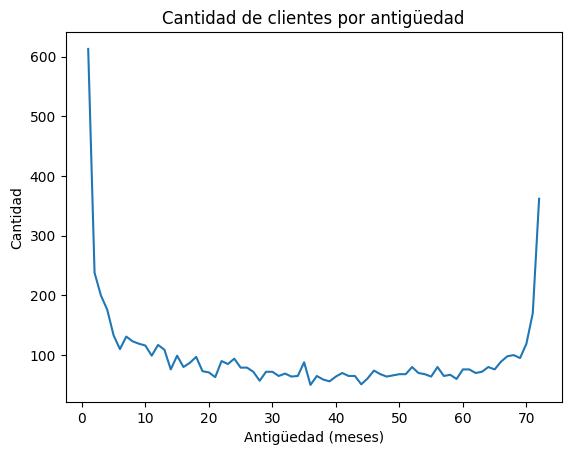

In [44]:

ax =df["tenure"].value_counts().sort_index().plot(kind="line", title="Cantidad de clientes por antigüedad")
ax.set_ylabel("Cantidad")
ax.set_xlabel("Antigüedad (meses)")



- Se observa una gran cantidad de clientes con 71 - 72 meses de antigüedad ¿Es posible que los datos estén censurados? ¿Se puede tratar de varias bases de datos combinadas?

## Variables de la cuenta (categóricas)

In [45]:

var = ["contract", "payment_method", "paperless_billing", "automatic_payment"]
var_labels = ["Contrato", "Método de pago", "Factura electrónica", "Pago automático"]
labels= [{},{}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}]

pretty_table(df, var, labels, var_labels)

Variable,Level,Total,Churn (%)
Contrato,month_to_month,"3,875",43%
,one_year,"1,472",11%
,two_year,"1,685",3%
Método de pago,bank_transfer_automatic,"1,542",17%
,credit_card_automatic,"1,521",15%
,electronic_check,"2,365",45%
,mailed_check,"1,604",19%
Factura electrónica,No,"2,864",16%
,Sí,"4,168",34%
Pago automático,No,"3,969",35%


- Contrataciones mes a mes son las que mayor porcentaje de cancelaciones presentan, superando el 40%.
- En tanto a método de pago, el cheque eletrónico es el único que posee un porcentaje elevado (45%).
- Clientes con factura electrónica y sin pago automático también presetan el doble de porcentaje de rechazo que sus contrapartes.

## Variables de Servicios

In [ ]:
var = ['phone_service', 'internet',]
var_labels = ["Servicio telefónico", "Servicio de internet"]
labels= [ {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}
          ]


pretty_table(df, var, labels, var_labels)

- Los clientes sin internet poseen una tasa de cancelación mucho menor al resto.
- Tener o no servicion telefónico no parce afectar el porcentaje de cancelación.

### Servicios de telefonía

In [ ]:
cols = ["multiple_lines"]
var_labels=["Multiples líneas"]
pretty_table(df.loc[df["phone_service"] == 1], cols, labels=[{0:"No", 1 :"Si"}], var_labels= var_labels)

Aquellos con multiples lineas presentan un porcenaje de cancelación apenas más elevado

### Servicios de internet

In [ ]:
df['subcription_total_group'] = df['subcription_total'].apply(lambda x: '0-2' if x <2.5 else '3-5' if x<5.5 else '6-7'  )
var = ['internet_service',
    'online_security', 'online_backup', 'device_protection',
       'tech_support', 'streaming_tv', 'streaming_movies',
       'subcription_total_group']
var_labels = ['Tipo de servicio de internet',
    'Seguridad online', 'Backup online', 'Protección del dispositivo',
       'Soporte técnico', 'Streaming TV', 'Streaming películas',
       'Subscripciones totales']

labels= [ {},
          {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"},
         {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"},
          {}
          ]


pretty_table(df.loc[df['internet']==1], var, labels, var_labels)

- Los servicios de streaming parecen tener poco efecto en el porcentaje de rechazo.
- En tanto a los demás servicios, a mayor cantidad se posea, menor es el porcentaje de rechazo.

## Analisis de correlación


In [ ]:
pretty_correlation(df)

#Informe Final

##Introducción

La evasión de clientes, también conocida como churn, cancelación o fuga de clientes, se refiere a la situación en la que un cliente decide dejar de utilizar un producto o servicio. Este fenómeno representa un problema importante para las empresas, ya que la pérdida de clientes afecta directamente su rentabilidad y crecimiento.

Según Bain & Company, en su informe Prescription for Cutting Costs, *un aumento del 5% en la retención de clientes puede generar un incremento en las ganancias de entre un 25% y un 95%*. Esto ocurre porque retener a un cliente suele ser menos costoso que adquirir uno nuevo, los clientes tienden a comprar más productos con el paso del tiempo y además pueden recomendar el servicio, atrayendo a nuevos clientes.

Dentro de este marco, la empresa analizada enfrenta una alta tasa de cancelaciones, lo que vuelve de vital importancia comprender qué factores están asociados a la pérdida de clientes. Este informe busca aportar evidencia a partir del análisis de datos, con el fin de obtener información útil que ayude a comprender y abordar el problema del churn.

## Limpieza y Tratamiento de Datos

El análisis se inició con la importación de la base de datos utilizando la biblioteca pandas. Los datos fueron obtenidos desde un repositorio de GitHub y se encontraban en formato JSON. La base contiene un total de 7.267 observaciones correspondientes a clientes individuales y seis variables principales: un identificador único del cliente (customerID), la variable objetivo Churn (yes/no) y cuatro variables que contienen información estructurada en forma de diccionarios anidados (customer, phone, internet y account ).
### General
- Se convirtieron los nombres de las variables a minúscula y snake_case para unificar formatos.
### CustomerID y Churn
- Se utilizó customerID para verificar la inexistencia de clientes duplicados o identificadores nulos.
- La variable Churn fue analizada inicialmente, detectándose que aproximadamente el 3% de los registros no contaban con esta información.
- Al no encontrarse patrones claros en el resto de las variables, estos registros fueron descartados, quedando pendientes para un análisis posterior.

### Variables del cliente (Customer)
- Se conviertieron los nombres de variables gender a gender_male y senior_citizen a senior_citizen_65 para mayor claridad.
- Las variables gender_male, senior_citizen_65, partner y dependents fueron revisadas en busca de valores nulos.
- Todas ellas fueron transformadas en variables indicadoras (0/1) para facilitar su análisis.
- Se creó la variable family, que toma el valor 1 si el cliente tiene pareja y/o dependientes, y 0 en caso contrario.
- Se encontraron 11 valores con tenure = 0, estos fueron descartados bajo la lógica de que no tuvieron la posibilidad de cancelar aún.
- Se creó la variable tenuere_log (logaritmo de tenure).

### Variables de telefonía (Phone)
- Las variables phone_servce y multiple_lines fueron evaluadas en busca de valores nulos e inconsistencias(por ejemplo, múltiples líneas sin servicio telefónico).
- Ambas variables fueron convertidas en variables indicadoras (0/1).

### Variables de internet (Internet)

- La variable internet_service fue descompuesta en variables indicadoras: dsl, fiber_optic y no_internet.
- Se analizaron las variables de suscripción:
    - online_security
    - online_backup
    - device_protection
    - tech_support
    - streaming_tv
    - streaming
- Se checkearon inconsistencias, como suscripciones activas en clientes sin servicio de internet.
- Se creó la variable subscrition_total (número de servicios contratados), subscrition_no_streaming (número de servicios contratados sin contar streaming) y streaming (indicadora de servicios de streaming)

### Variables de cuenta y facturación (Account)

- Se analizaron las variables:

     - contract
     - paperless_billing
     - payment_method
     - charges_total
     - charges_monthly

- contract presentaba los mismos planes escritos de diversas formas, fueron estandarizados y transformado en variables indicadoras: two_year, one_year y month_to_month
- payment_method fue subdividido en variables indicadoras según el método utilizado.
- Basadonse en payment_method se creó la variable automatic, que toma el valor 1 para pagos automáticos.
- Se creó la variable charges_average, que aproxima el gasto medio del cliente considerando su antigüedad.
- Se aplicaron transformaciones logarítmicas a charges_total, charges_monthly y charges_average.

## Análisis Exploratorio de Datos

### Churn

Se observa que de la totalidad de los clientes el 27% canceló el servicio. A falta de otra referencia se utilizará este valor durante el trabajo.
Aquellos grupos con porcentajes mucho mayores a 27% representan los factores a mejorar mientras que aquellos grupos menores a 27% serán tratados como que no presentasen problemas.

In [ ]:

counts = df['churn'].value_counts().sort_index()
total = counts.sum()
labels = ['No canceló', 'Canceló']
colors = ['C0', 'red']

def autopct_format(pct):
    n = int(round(pct * total / 100))
    return f'{pct:.0f}%\n({n:,})'

plt.figure()

wedges, texts, autotexts = plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct=autopct_format,
    startangle=90,
    labeldistance=1.25,   # etiquetas más afuera
    pctdistance=0.75      # porcentajes más adentro
)

# Recuadros y negrita para porcentajes
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_bbox(dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black"
    ))

# Recuadros y negrita para etiquetas
for text in texts:
    text.set_fontweight('bold')
    text.set_bbox(dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",

    ))


plt.title('Distribución de churn de clientes')
plt.axis('equal')
plt.show()

### Tenure

La antigüedad del cliente (en meses).

- Podemos observar que los primeros 5 meses son los que presentan una tasa de cancelación más elevada.
- Al avanzar el tiempo, la tasa de cancelación baja, en particular, entre los meses 18 y 24  se alcanza la tasa de rechazo promedio (27%)
- Existe una suerte de pico a los 72 meses. Posiblemente los datos estén censurados (72 meses representando "72 meses o más")


In [ ]:
comboplot(data = df , var = "tenure", barwidth=1, ylim= [0,750],
          xlabel = "Antigüedad en meses (tenure)",
          title = "Churn según antigüedad")
print("Se añade una línea horizontal representando el churn promedio de la base : 27%")


### Variables del cliente

- No parece haber diferencia entre hombres y mujeres.
- Los ciudadanos mayores de 65 años poseen casi el doble de la tasa de cancelación que los menores de 65 años.
- Aquellos clientes sin pareja / hijos presetan una mayor tasa de cancelación.






In [ ]:
#pretty table de las variables del cliente
df['tenure_group'] = df['tenure'].apply(lambda x: " 1 a 5" if x< 5.5 else " 6 a 24" if x < 24.5 else "25+" )
var = ["gender_male", "senior_citizen_65", "family", "partner", "dependents", 'tenure_group']
var_labels = ["Género", "Edad", "Familia", "Pareja", "Dependientes", 'Antigüedad (meses)']
labels= [{0: "Mujer", 1: "Hombre"},{0: "0-64", 1: "65+"}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}, {}]

table = pretty_table(df, var, labels, var_labels)
df= df.drop(columns=['tenure_group'])

table


### Variables de la cuenta


- Los clientes con contractos del tipo mensual, factura electrónica y cheque electronico presentan una tasa de cancelación mucho mayor que los demás.
- Los clientes con contraros anual o bianual, sin factura electrónica y que optaron por cualquier otro medio de pago presentan una menor tasa de cancelación.
- Se observa que a mayor costo del plan mayor tasa de cancelación.


In [47]:
#tabla de payment method
df["charges_monthly_group"] = df["charges_monthly"].apply(lambda x: "$15-$45" if x <45 else "$45-$75" if x<75 else "$75+" )

var = ["contract",
       "paperless_billing",
       "payment_method",
       "automatic_payment",
       "charges_monthly_group",]

var_labels = ["Contrato", "Factura electrónica", "Método de pago", "Pago automático", "Cuenta mensual"]

labels= [{"month_to_month": "Mensual", "one_year": "Anual" , "two_year":"Bianual"},
 {0: "No", 1: "Sí"},
 {"bank_transfer_automatic" : "Transferencia bancaria",
  "credit_card_automatic": "Tarjeta de crédito",
  "electronic_check": "Cheque electrónico",
  "mailed_check": "Cheque postal"
  },
  {0: "No", 1: "Sí"},
         {}]


table = pretty_table(df, var, labels, var_labels)
df = df.drop(columns=["charges_monthly_group" ])

table


Variable,Level,Total,Churn (%)
Contrato,Mensual,"3,875",43%
,Anual,"1,472",11%
,Bianual,"1,685",3%
Factura electrónica,No,"2,864",16%
,Sí,"4,168",34%
Método de pago,Transferencia bancaria,"1,542",17%
,Tarjeta de crédito,"1,521",15%
,Cheque electrónico,"2,365",45%
,Cheque postal,"1,604",19%
Pago automático,No,"3,969",35%


####Relación Gastos mensuales, antigüedad y porcentaje de rechazos
- Para clientes nuevos (menos de 6 meses) la tasa de cancelación para planes de costo \$70 es mayor al 60%. Incluso para planes de \$30 a \$70 sigue estando arriba  del 40%
- Para clientes intermedios (6 meses a 2 años) la cancelación está arriba del promedio (27%) para plances de \$50 o más.
- Para los clientes más antigüos (más de dos años) la tasa de cancelación se mantiene debajo del promedio.
- Planes entre \$55 y \$65 presentan una tasa de cancelación menor a la esperada. Un caso similar ocurre para planes entre \$105 y \$115

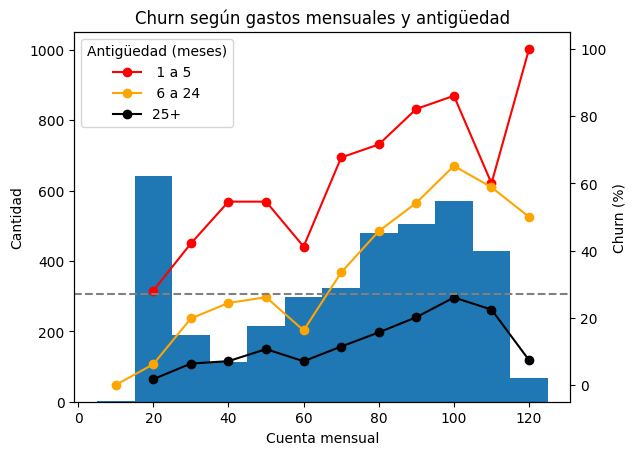

Se añade una línea horizontal representando el churn promedio de la base : 27%


In [49]:
#comboplot de log_gastos y churn
#def comboplot(data, var, group = None,
#              xlabel = None, xlim=None , ylim=None, churnlim = None , xticks=None,
#              title = None, legend=None, barwidth = None , color = None):


df["charges_average_group"] = df["charges_average"].apply(lambda x: round(x/10, 0)*10)
df['tenure_group'] = df['tenure'].apply(lambda x: " 1 a 5" if x< 5.5 else " 6 a 24" if x < 24.5 else "25+" )

comboplot(df, var = "charges_average_group", group= "tenure_group",
          barwidth=10, color = {" 1 a 5" : "red", " 6 a 24" : "orange",  "25+" : "black"} ,
          ylim = [0,1050], xlabel = "Cuenta mensual",
          title = "Churn según gastos mensuales y antigüedad", legend = "Antigüedad (meses)")

df = df.drop(columns = ["charges_average_group", "tenure_group"] )

print("Se añade una línea horizontal representando el churn promedio de la base : 27%")


### Variables de servicio

- Poseer servicio telefónico parece  no afectar la tasa de cancelación. Igualmente para multiples lineas.

- En tanto al servicio de internet, aquellos sin el presentan mucha menor tasa de cancelación que aquellos con el.

In [50]:
#tabla de internet/telefono, tabla de multiples lineas

var = ['phone_service', 'internet',]
var_labels = ["Servicio telefónico", "Servicio de internet"]
labels= [ {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}
          ]

pretty_table(df, var, labels, var_labels)


Variable,Level,Total,Churn (%)
Servicio telefónico,No,680,25%
,Sí,"6,352",27%
Servicio de internet,No,"1,520",7%
,Sí,"5,512",32%
Total,,"7,032",27%


In [51]:

var = ['multiple_lines']
var_labels = ['Líneas multiples']

labels= [  {0: "No", 1: "Sí"}]
pretty_table(df.loc[df['phone_service']==1], var, labels, var_labels)


Variable,Level,Total,Churn (%)
Líneas multiples,No,"3,385",25%
,Sí,"2,967",29%
Total,,"6,352",27%


### Variables de internet


De los clientes que tienen servicio de internet se observa que la tasa de cancelación es especialmente alta para:
- clientes con fibra óptica
- clientes que contratan 2 o menos servicios (contando streaming)
- clientes que contratan 1 o menos servicios (que no sea streaming).

En general, los servicios de streaming por si solo no parecen afectar la tasa de cancelación.

In [53]:
df['subcription_total_group'] = df['subcription_total'].apply(lambda x: '0-2' if x <2.5 else '3-4' if x<4.5 else '5-6'  )
df['subcription_no_streaming_group'] = df['subcription_no_streaming'].apply(lambda x: '0-1' if x <1.5 else '2' if x<2.5 else '3-4'  )

var = ['internet_service',
    'online_security', 'online_backup', 'device_protection',
       'tech_support', 'streaming_tv', 'streaming_movies', 'streaming',
       'subcription_total_group', 'subcription_no_streaming_group',]

var_labels = ["Tipo de servicio de internet", 'Seguridad online', 'Back-up online', 'Protección de dispositivo',
              'Soporte técnico', 'Streaming TV', 'Streaming movies', "Streaming",
              "Cantidad de suscripciones", 'Cantidad de suscripciones (sin streaming)']
labels= [ {"DSL": "DSL", "Fiber optic": "Fibra óptica"},
          {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"},
         {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"}, {0: "No", 1: "Sí"},
          {},  {}
          ]

table = pretty_table(df.loc[df['internet']==1], var, labels, var_labels)

df.drop(columns = ["subcription_total_group", "subcription_no_streaming_group"])
table

Variable,Level,Total,Churn (%)
Tipo de servicio de internet,DSL,"2,416",19%
,Fibra óptica,"3,096",42%
Seguridad online,No,"3,497",42%
,Sí,"2,015",15%
Back-up online,No,"3,087",40%
,Sí,"2,425",22%
Protección de dispositivo,No,"3,094",39%
,Sí,"2,418",23%
Soporte técnico,No,"3,472",42%
,Sí,"2,040",15%


In [ ]:

comboplot(df.loc[df['internet'] == 1], var='subcription_total', barwidth=0.75,
                    title = "Churn según cantidad de servicios suscriptos",
                    xlabel=  "Cantidad de servicios suscriptos")

print("Se añade una línea horizontal representando el churn promedio de la base : 27%")


In [ ]:
comboplot(df.loc[df['internet'] == 1], var='subcription_no_streaming', barwidth=0.75,
          title = "Churn según cantidad de servicios suscriptos (sin streaming)",
          xlabel=  "Cantidad de servicios suscriptos")

print("Se añade una línea horizontal representando el churn promedio de la base : 27%")


###  Correlación


- Se observa que la tasa de cancelación esta correlacionada principalmente con:

    - Antigúedad (y su logaritmo)
    - Gastos mensuales (y su logaritmo)
    - Gastos totales (y su logarimto)
    - Edad (mayor de 65 años)
    - Tipo de servicio de internet (DSL, fibra óptica, ningúno)
    - Cantidad de servicios suscripto (sin contar streaming).
    - Contrato (mensual, anual, bianual)
    - Método de pago

- Salvo el contrato, todas las correlaciones parecen ser débiles.
- Aplicar logaritmo parece incrementar levemente la correlación.
- Se observan además variables asociadas entre ellas, en particular las siguientes podrían afectar a los modelos:
    - Familia con Pareja y Dependientes
    - Suscripciones totales (con y sin streaming) y las distintas suscripciones.
    - Streaming con streaming TV y Streaming Movies
    - Gastos Totales y Antigüedad
    - Gastos mensuales con las distintas suscripciones y el total de suscripciones.
    - Contrato y Antigüedad
    - Tipo de servicio de internet y gastos mensuales.




In [ ]:
vars = [ 'churn', 'gender_male', 'senior_citizen_65',
        'family','partner', 'dependents', 'tenure', 'tenure_log',
         'phone_service', 'multiple_lines', 'internet',
         'online_security', 'online_backup', 'device_protection', 'tech_support',
         'streaming_tv', 'streaming_movies', 'streaming',
         'subcription_total', 'subcription_no_streaming',
       'paperless_billing', 'charges_monthly',  'charges_monthly_log',
       'charges_total',    'charges_average_log',
         'dsl', 'fiber_optic', 'no_internet',
       'month_to_month', 'one_year', 'two_year',
         'bank_transfer_automatic',  'credit_card_automatic',
         'electronic_check', 'mailed_check',
       'automatic_payment']
pretty_correlation(df, vars)

----
## Conclusiones e Insights

- La tasa de cancelación promedio es 27%.
- Antigüedad y costo del plan afectan la tasa de cancelación, se observó que:
    - A menor antigüedad y mayor precio del plan, mayor tasa de cancelación.
    - Los primeros 5 meses de los clientes presentan la mayor tasa de cancelación. Alcanzando el promedio para los planes de $20.
    - Para antigüedades de 6 meses a 2 años, los planes de hasta $60 se mantienen debajo del promedio.
    - Para antigüedades mayores a 2 años, siempre se mantienen con una cancelación debajo del promedio.
    - Los planes con costo \$60 presentan una tasa de cancelación menor a la esperada.

- En tanto a las caracetrísticas demográficas:
    - No parece haber diferencia entre hombres y mujeres.
    - Mayores de 65 años poseen mayor tasa de cancelación.
    - Clientes sin pareja / hijos presetan una mayor tasa de cancelación.


- Clientes sin internet presentan tasa de cancelación mucho menor que el promedio.
- De aquellos que poseen internet:
    - Fibra óptica presenta más cancelaciones que DSL.
    - Clientes suscriptos a ningún o un servicio (sin contar streaming) tienen mayot tasa de cancelación
    - Los servicios de streaming no parecen afectar la cancelación.

- En cuanto al tipo de plan:
    - Los clientes con contractos del tipo mensual, factura electrónica y cheque electronico presentan una tasa de cancelación mucho mayor que los demás.
    - Los clientes con contraros anual o bianual, sin factura electrónica y que optaron por cualquier otro medio de pago presentan una menor tasa de cancelación.
    - Se observa que a mayor costo del plan mayor tasa de cancelación.

- Un análisis de correlación mostró que la cancelación esta asociada principalmente a:
    - La antigüedad en meses.
    - Los gastros totales (fuertemente asociado a la antigüedad).
    - El tipo de servicio de internet (DSL, fibra óptica, ninguno).
    - Método de pago (mayoritariamente a cheque electrónico).
    - Tipo de contrato (mensual, anual, bianual)
- Y en menor medida:
    - Los gastos mensuales
    - Familia, pareja y dependientes.
    - Edad.
    - Cantidad de suscripciones (sin streaming).
    - Factura electrónica



----
## Recomendaciones


Se proponen los siguientes items accionables, siempre teniendo en cuenta que se requiere un análisis en profundidad del equipo de análisis de datos e inteligencia de mercado.

1. Conservación de clientes nuevos

    - Enfocar los esfuerzos (promociones, descuentos) en los clientes nuevos (menos de 6 meses). Pasado este momento la tasa de cancelación baja mucho.
    
2. Reajuste del costo de los planes

    - Es fundamental optimizar los costos de los planes y servicios para disminuir la cancelación.
    - Para usuarios nuevos, planes de costo $20 son los únicos cuyo tasa de cancelación alcanza el promedio.
    - Para usuarios con 6 a 24 meses de antigüedad, planes de costo inferiores \$60 mantienen la cancelación debajo del promedio
    - En particular los planes de costo \$60 presentan una tasa de cancelación menor a la esperado, surgiendo la posibilidad de ofrecer dicho plan a aquellos pagando más o incluso a aquellos clientes con planes levemente más baratos.

El valor de los clientes con perfiles de baja tasa es mucho mayor al del resto de los clientes, si bien un análisis  de una base de datos especializada arrojaría resultados más precisos, se puede esperar que las siguientes estrategias aporten valor:

3. Protección de los clientes.
    

    - Preparar ofertas, descuentos, beneficios extra para los clientes que presentan perfiles de riesgo, es decir:
        - clientes nuevos (menos de 6 meses).
        - Clientes con internet por fibra óptica.
        - Planes más caros.
        - Suscriptos a menos de 2 servicios (sin contar streaming).
        - Mayores de 65 años.
        - Sin pareja ni dependientes.
        - Con plan mensual.
        - Que utilizen cheque electrónico.
        - Con factura electrónica
    - En particular, cambiar la modalidad de pago, el tipo de contrato (anual o bianual) u ofrecer promociones de suscripciones pordría ayudar.


4. Recaptura de clientes con baja chance de cancelación.

    - En lugar de llamar nuevos clientes, invertir esfuerzo en convencer a clientes de bajo riesgo de volver a la empresa
        - clientes de mayor antigüedad (más de 2 años).
        - Clientes sin internet o por DSL.
        - Planes más baratos.
        - Suscriptos a 2 o más servicios (sin contar streaming).
        - Menores de 65 años.
        - Con pareja y/o dependientes.
        - Con plan anual o bianual.
        - Que no utilizen cheque electrónico.
        - Sin factura electrónica

5. Captura de clientes de bajo riesgo.
    - Al intentar conseguir nuevos clientes, focalizar en personas menores de 65 años, con familia (pareja o dependientes), con infraestructura para internet por DSL.
    - Ofrecerles los servicios que presenten menor tasa de cancelación: sin internet o bien tratar de conseguir al menos 3 servicios, contratos a uno o dos años, métodos de pago automáticos o bien por *mailed check*.

6. Mejora del servicio
    - Internet por fibra óptica presentó una tasa de cancelación muy alta. Esto requiere una investigación más a fondo.
    - De la misma forma, *electronic check* fué el único medio de pago con tasa de cancelación alta. Se puede fomentar otros medios de pagos o bien intentar averiguar si este medio presenta algún problema.
    - Los planes de \$60 y \$110 poseen menor tasa de cancelación que otros planes. Se debe investigar la causa.


----
## Limitaciones

- Este análisis se realizó asumiendo que la base de datos representa las cancelaciones (y no cancelaciones) dentro de un mes dado y no a lo largo del tiempo, de ser el segundo caso el análisis no es valido y se requeriría un enfoque análisis de datos de duración/supervivencia.
- No se tiene información de planes o descuentos aplicados. La estructura de los gastos mensuales es propia de una mezcla de poblaciones (tipo de productos distintos).
- Faltan variables básicas como edad del cliente, nivel de estudios, profesión (o situación laboral), raza, nivel socio-económico, dirección o al menos barrio / ciudad.
- Información sobre el uso del servicio podría ayudar a identificar perfiles.